# Plot Mortality Notebook

In this notebook we will plot the mortality. We will ensure publication-ready quality svgs so they can be me merged easily into multiplots with inkscape.

We will load the uv venv that is located in our parent directory. This can be selected as the kernel is vscode.

In [5]:
# import libs

import os
import glob
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

In [6]:
# set some vars and make a small helper func.
# input our master parquet dir...
INPUT_DIR = "../H5toParquet/output/final/" 
OUTPUT_TIMELINE_IMG = "./Mortality_Plots/mortality_timeline.svg"
OUTPUT_TIMELINE_IMG_PUBREADY = "./Mortality_Plots/mortality_timeline_pubready.svg"
OUTPUT_STATS_IMG = "./Mortality_Plots/mortality_timeline_stats.svg"

# helper function to grab the rep # from each file name
def extract_rep_num(rep_string):
    """Extracts the integer from the replicate string for clean numerical sorting."""
    match = re.search(r'rep(\d+)', str(rep_string).lower())
    return int(match.group(1)) if match else 0

# setting to make svg rendered text editable
plt.rcParams['svg.fonttype'] = 'none'

In [7]:
# grab the parquet files and the total time alive (runs in about two minutes on my local home machine... a minute on the workstation)

# if not to check if we grabbed parquet files...
parquet_files = glob.glob(os.path.join(INPUT_DIR, "*_master.parquet"))
if not parquet_files:
    raise FileNotFoundError(f"No master parquet files found in {INPUT_DIR}.")

print(f"Found {len(parquet_files)} master files. Extracting lifespans...")


# make a empty list then loop over the parquet files and read neccessary columns, 
data = []
for f in parquet_files:
    # load columns
    df = pd.read_parquet(f, columns=['individual', 'global_frame', 'treatment', 'replicate'], engine='pyarrow')
    
    # calculate elapsed_hours with framerate (60 fps = 216,000 frames per hour)
    df['elapsed_hours'] = df['global_frame'] / 216000.0
    
    # grab lifespan for each individual by grabbing max 
    summary = df.groupby(['treatment', 'replicate', 'individual'])['elapsed_hours'].max().reset_index()
    data.append(summary)

# combine all data
master_summary = pd.concat(data, ignore_index=True)
# rename elapsed hours column to lifespan
master_summary = master_summary.rename(columns={'elapsed_hours': 'lifespan'})

# clean and prepare labels, using helper function from above
master_summary['rep_num'] = master_summary['replicate'].apply(extract_rep_num)
master_summary['y_label'] = "Rep " + master_summary['rep_num'].astype(str) + " - Ind " + master_summary['individual'].astype(str)

# split and sort into LD and DD datasets
df_ld = master_summary[master_summary['treatment'].str.contains('LD', case=False, na=False)].copy()
df_dd = master_summary[master_summary['treatment'].str.contains('DD', case=False, na=False)].copy()

# sort data from highest to lowest
df_ld = df_ld.sort_values(by=['rep_num', 'individual'], ascending=[True, True]).reset_index(drop=True)
df_dd = df_dd.sort_values(by=['rep_num', 'individual'], ascending=[True, True]).reset_index(drop=True)

# preview the processed data
display(master_summary.head())

Found 16 master files. Extracting lifespans...


,treatment,replicate,individual,lifespan,rep_num,y_label
0,LD-diet,rep7,1,78.999995,7,Rep 7 - Ind 1
1,LD-diet,rep7,2,40.999995,7,Rep 7 - Ind 2
2,LD-diet,rep7,3,95.999995,7,Rep 7 - Ind 3
3,LD-diet,rep7,4,63.999995,7,Rep 7 - Ind 4
4,LD-diet,rep7,5,92.999995,7,Rep 7 - Ind 5


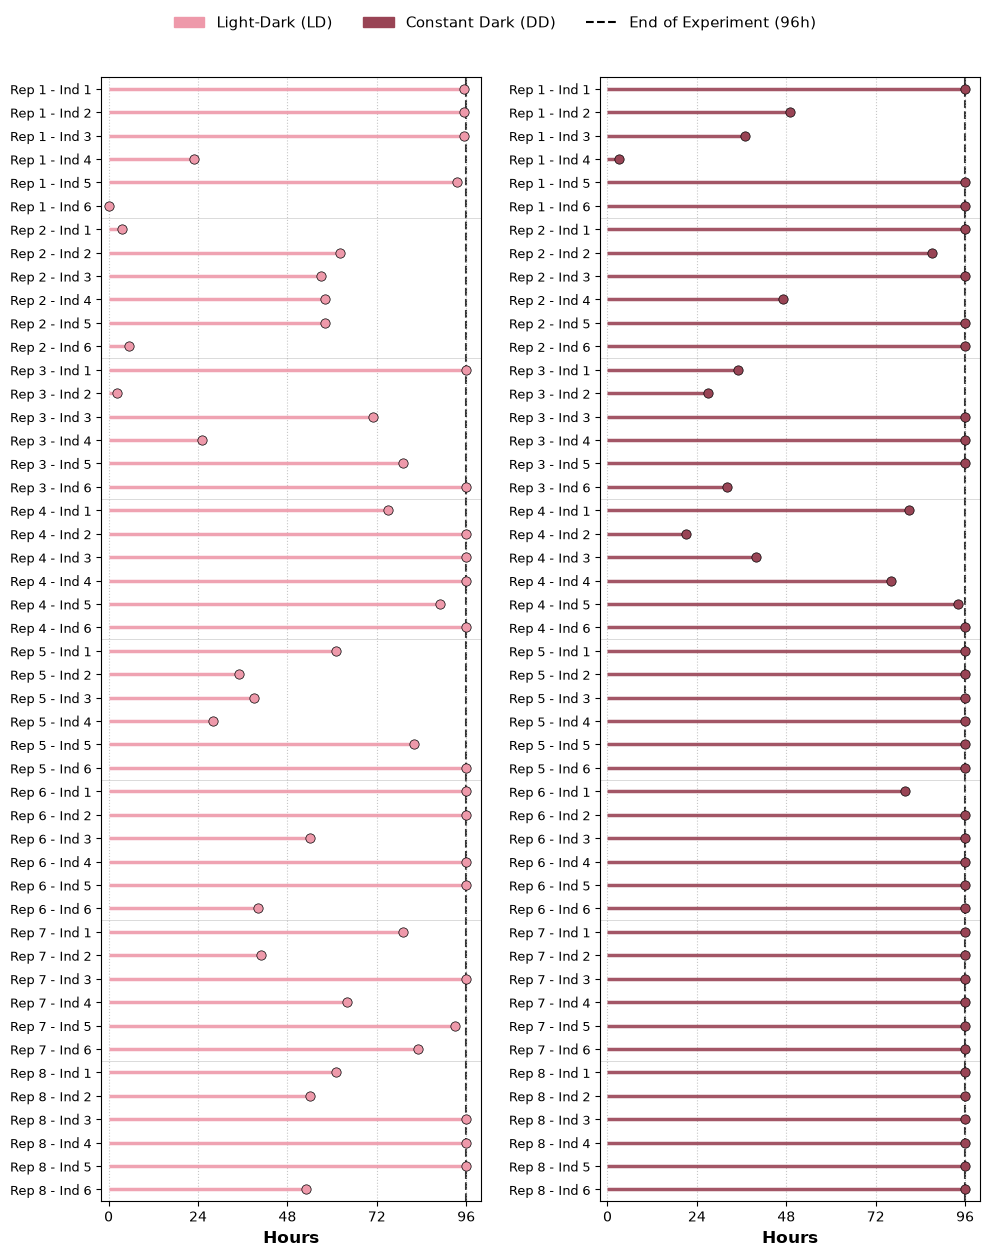

Saved to: ./Mortality_Plots/mortality_timeline.svg


In [4]:
# generating the lolipop plot

# setting tol colors
color_ld = '#EE99AA'  # Light Red
color_dd = '#994455'  # Dark Red

# set maximum rows based on the length of each df (n)
max_rows = max(len(df_ld), len(df_dd))

# set subplots for ld and dd and fig size accordingly.
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, max(6, max_rows * 0.25)))


def plot_panel(ax, df, color):
    y_positions = range(len(df))
    # draw Lifespan line
    ax.hlines(y=y_positions, xmin=0, xmax=df['lifespan'], color=color, alpha=0.9, linewidth=2.5, zorder=2)
    # draw End Dot
    ax.scatter(df['lifespan'], y_positions, color=color, s=45, zorder=3, edgecolors='black', linewidths=0.5)
    # 96 h line
    ax.axvline(x=96, color='black', linestyle='--', alpha=0.8, zorder=1)

    # some arguments for y labels (might need to make smaller), set x labels at 24 h
    ax.set_yticks(y_positions)
    ax.set_yticklabels(df['y_label'], fontsize=9)
    ax.set_xticks([0, 24, 48, 72, 96])
    # set total lim just above and below for some margins
    ax.set_xlim(-2, 100) 
    # y lim margins based on n...
    ax.set_ylim(len(df) - 0.5, -0.5)

    # labels
    ax.set_xlabel('Hours', fontsize=12, fontweight='bold')
    ax.grid(axis='x', linestyle=':', alpha=0.7, zorder=0)

    # add seperating lines for video replicates
    rep_shifts = df['rep_num'].drop_duplicates().index.tolist()
    for shift_idx in rep_shifts[1:]:
        ax.axhline(y=shift_idx - 0.5, color='grey', linestyle='-', linewidth=0.5, alpha=0.4)

# plot panels
plot_panel(ax1, df_ld, color_ld)
plot_panel(ax2, df_dd, color_dd)

# add legend
ld_patch = mpatches.Patch(color=color_ld, label='Light-Dark (LD)')
dd_patch = mpatches.Patch(color=color_dd, label='Constant Dark (DD)')
end_line = plt.Line2D([0], [0], color='black', linestyle='--', label='End of Experiment (96h)')
fig1.legend(handles=[ld_patch, dd_patch, end_line], loc='upper center', 
            bbox_to_anchor=(0.5, 1.05), frameon=False, fontsize=11, ncol=3)

# adjust layout...
fig1.tight_layout(w_pad=2.0)

# display and save
plt.show()
fig1.savefig(OUTPUT_TIMELINE_IMG, bbox_inches='tight')
print(f"Saved to: {OUTPUT_TIMELINE_IMG}")

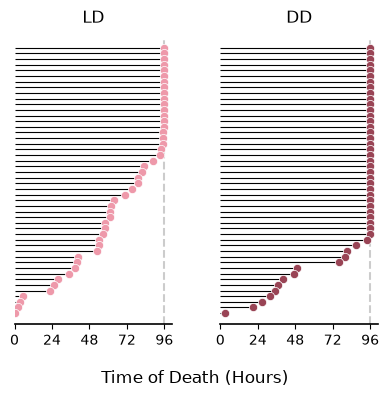

Saved dense timeline plot to: ./Mortality_Plots/mortality_timeline_pubready.svg


In [5]:
# the plot above is good but we might want something more discrete that can fit into a multiplot

# colors for the scatter points
color_ld = '#EE99AA'  # Light Red
color_dd = '#994455'  # Dark Red

# quick funciton 
def prep_dense_waterfall_data(df):
    """
    sorts individuals by lifespan within each replicate.
    """
    # sort first by rep num  then lifespan
    df_sorted = df.sort_values(by=['lifespan'], ascending=[False]).copy()
    
    # Create a simple 0 to N sequence for the y-positions
    df_sorted['y_pos'] = range(len(df_sorted))
    
    return df_sorted

# Set up the figure, small to be used for a multiplot down the road.
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(4, 4))

def plot_dense_panel(ax, df, color, title):
    # Prepare the sorted data
    df_plot = prep_dense_waterfall_data(df)
    
    # 1. draw stick
    ax.hlines(y=df_plot['y_pos'], xmin=0, xmax=df_plot['lifespan'], 
              color='black', alpha=1, linewidth=0.8, zorder=1)
    
    # 2. draw the lolipop
    ax.scatter(df_plot['lifespan'], df_plot['y_pos'], 
               color=color, s=35, zorder=2, edgecolors='white', linewidths=0.5)
    
    # 3. draw 96 h line for video end
    ax.axvline(x=96, color='black', linestyle='--', alpha=0.2, zorder=0)

    # drop y axis labels completely
    ax.set_yticks([])
    ax.set_yticklabels([])
    
    # x-axis formatting
    max_x = max(df_plot['lifespan'].max(), 96)
    ax.set_xticks(np.arange(0, max_x + 24, 24))
    # small margin baed on max x...
    ax.set_xlim(0, max_x + 5)
    
    # invert Y-axis so longest lifespan is at the top
    ax.set_ylim(df_plot['y_pos'].max() + 2, -2)

    # move to outside of each individual plot and to main plot...
    #ax.set_xlabel('Time of Death (Hours)', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=12, pad=10)
    
    # clean up borders.
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False) # Remove left spine since there are no ticks
    ax.spines['bottom'].set_linewidth(1.2)

# plot each of the panels
plot_dense_panel(ax1, df_ld, color_ld, 'LD')
plot_dense_panel(ax2, df_dd, color_dd, 'DD')

# add the x title outside of the plot
fig1.supxlabel('Time of Death (Hours)', fontsize=12, y=0.02)

# adjust layout to tight
fig1.tight_layout(w_pad=3.0)

# show the plot, save to disc as svg
plt.show()
fig1.savefig(OUTPUT_TIMELINE_IMG_PUBREADY, bbox_inches='tight', dpi=300)
print(f"Saved dense timeline plot to: {OUTPUT_TIMELINE_IMG_PUBREADY}")

Stats -> LD Median: 79.00h | DD Median: 96.00h
Stats -> Wilcoxon test: U = 730.500, p-value = 9.2283e-04 (***)


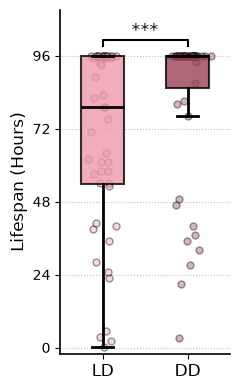

Saved stats plot to: ./Mortality_Plots/mortality_timeline_stats.svg


In [6]:
# running some stats on the mortality data. trying to match general formatting between both plots (font sizes etc.)

# dropping any NA values for posterity. shouldnt be any...
ld_data = df_ld['lifespan'].dropna()
dd_data = df_dd['lifespan'].dropna()

# calculate mann-whitney U two sided test
u_stat, p_val = stats.mannwhitneyu(ld_data, dd_data, alternative='two-sided')

# determine significance asterisks with conditionals
if p_val <= 0.0001: sig = '****'
elif p_val <= 0.001: sig = '***'
elif p_val <= 0.01: sig = '**'
elif p_val <= 0.05: sig = '*'
else: sig = 'ns'

# print out results...
print(f"Stats -> LD Median: {ld_data.median():.2f}h | DD Median: {dd_data.median():.2f}h")
print(f"Stats -> Wilcoxon test: U = {u_stat:.3f}, p-value = {p_val:.4e} ({sig})")

# start the fig, smaller panel here
fig2, ax_stat = plt.subplots(figsize=(2.5,4))

# Force white background for the figure and axes
fig2.patch.set_facecolor('white')
ax_stat.set_facecolor('white')

# set boxplot 
bplot = ax_stat.boxplot([ld_data, dd_data], positions=[0, 1], widths=0.5, 
                        patch_artist=True, showfliers=False, zorder=3)

# style the boxes w our palette
colors = [color_ld, color_dd]
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

# thicker styling for lines (likely remove)
for element in ['medians', 'whiskers', 'caps']:
    for item in bplot[element]:
        item.set(color='black', linewidth=2.0)

# overlay jitter points
ld_jitter = np.random.normal(0, 0.08, size=len(ld_data))
dd_jitter = np.random.normal(1, 0.08, size=len(dd_data))

ax_stat.scatter(ld_jitter, ld_data, color=color_ld, alpha=0.4, s=25, zorder=2, edgecolors="black")
ax_stat.scatter(dd_jitter, dd_data, color=color_dd, alpha=0.4, s=25, zorder=2, edgecolors="black")

# significance Bracket
y_max = max(ld_data.max(), dd_data.max())
bracket_y = y_max + 3  
bracket_h = 2          

ax_stat.plot([0, 0, 1, 1], [bracket_y, bracket_y+bracket_h, bracket_y+bracket_h, bracket_y], 
             lw=1.5, color='black')

ax_stat.text(0.5, bracket_y + bracket_h + 0.5, sig, ha='center', va='bottom', 
             color='black', fontsize=12)

# formatting
ax_stat.set_xticks([0, 1])
ax_stat.set_xticklabels(['LD', 'DD'], fontsize=12)
ax_stat.set_ylabel('Lifespan (Hours)', fontsize=12)
ax_stat.set_yticks([0, 24, 48, 72, 96])
ax_stat.set_ylim(-2, bracket_y + bracket_h + 10) 
ax_stat.grid(axis='y', linestyle=':', alpha=0.8, zorder=0)

# clean up spines (borders) to match the lollipop plot
ax_stat.spines['top'].set_visible(False)
ax_stat.spines['right'].set_visible(False)
ax_stat.spines['bottom'].set_linewidth(1.2)
ax_stat.spines['left'].set_linewidth(1.2)

# adjust layout and plot
fig2.tight_layout()
plt.show()

# save to svg
fig2.savefig(OUTPUT_STATS_IMG, bbox_inches='tight', dpi=300)
print(f"Saved stats plot to: {OUTPUT_STATS_IMG}")

below we can update our analysis to annotate escapees

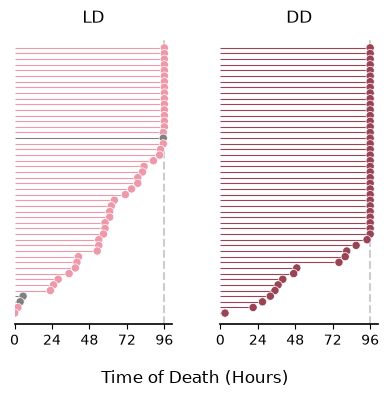

Saved updated dense timeline plot to: ./Mortality_Plots/mortality_timeline_pubready.svg
Stats -> LD (n=45) Median: 79.00h
 IQR:
0.25    53.999995
0.75    95.999995
Name: lifespan, dtype: float64
 DD (n=48) Median: 96.00h
 IQR:
0.25    85.499995
0.75    95.999995
Name: lifespan, dtype: float64

Stats -> Wilcoxon test: U = 714.500, p-value = 2.3903e-03 (**)


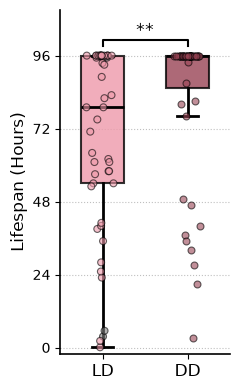

Saved updated stats plot to: ./Mortality_Plots/mortality_timeline_stats.svg


In [ ]:
# grab escaped individuals
escaped_mask = (
    ((df_ld['rep_num'] == 1) & (df_ld['individual'] == 1)) |
    ((df_ld['rep_num'] == 2) & (df_ld['individual'] == 1)) |
    ((df_ld['rep_num'] == 2) & (df_ld['individual'] == 6))
)
df_ld['is_escaped'] = escaped_mask
df_dd['is_escaped'] = False

color_ld = '#EE99AA'  # Light Red
color_dd = '#994455'  # Dark Red

# waterfall plot (sorted lolipop)
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(4, 4))

def plot_dense_panel(ax, df, base_color, title):
    # prep sorted ata
    df_plot = prep_dense_waterfall_data(df)
    
    # colors but grey if someone escaped
    point_colors = ['grey' if escaped else base_color for escaped in df_plot['is_escaped']]
    
    # sticks
    ax.hlines(y=df_plot['y_pos'], xmin=0, xmax=df_plot['lifespan'], 
              colors=point_colors, alpha=1, linewidth=0.8, zorder=1)
    
    # lolipop
    ax.scatter(df_plot['lifespan'], df_plot['y_pos'], 
               c=point_colors, s=35, zorder=2, edgecolors='white', linewidths=0.5)
    
    # end of vid lines
    ax.axvline(x=96, color='black', linestyle='--', alpha=0.2, zorder=0)

    # format
    ax.set_yticks([])
    ax.set_yticklabels([])
    
    max_x = max(df_plot['lifespan'].max(), 96)
    ax.set_xticks(np.arange(0, max_x + 24, 24))
    ax.set_xlim(0, max_x + 5) 
    
    # invert axis
    ax.set_ylim(df_plot['y_pos'].max() + 2, -2)
    ax.set_title(title, fontsize=12, pad=10)
    
    # Clean up borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.2)

# plot each panel
plot_dense_panel(ax1, df_ld, color_ld, 'LD')
plot_dense_panel(ax2, df_dd, color_dd, 'DD')

# Add titles and format layout
fig1.supxlabel('Time of Death (Hours)', fontsize=12, y=0.02)
fig1.tight_layout(w_pad=3.0)

plt.show()
fig1.savefig(OUTPUT_TIMELINE_IMG_PUBREADY, bbox_inches='tight', dpi=300)
print(f"Saved updated dense timeline plot to: {OUTPUT_TIMELINE_IMG_PUBREADY}")



# boxplot but with only valid mortality, escapees removed

# prep data
ld_df_clean = df_ld.dropna(subset=['lifespan']).reset_index(drop=True)
dd_df_clean = df_dd.dropna(subset=['lifespan']).reset_index(drop=True)

# all data for jitter points
ld_data_all = ld_df_clean['lifespan']
dd_data_all = dd_df_clean['lifespan']

# stat and boxplot data
ld_data_stats = ld_df_clean[~ld_df_clean['is_escaped']]['lifespan']
dd_data_stats = dd_df_clean['lifespan'] # no escapes

# stat tests
u_stat, p_val = stats.mannwhitneyu(ld_data_stats, dd_data_stats, alternative='two-sided')

# sig logic
if p_val <= 0.0001: sig = '****'
elif p_val <= 0.001: sig = '***'
elif p_val <= 0.01: sig = '**'
elif p_val <= 0.05: sig = '*'
else: sig = 'ns'

# print summary and n
print(f"Stats -> LD (n={len(ld_data_stats)}) Median: {ld_data_stats.median():.2f}h\n IQR:\n{ld_data_stats.quantile([0.25, 0.75])}\n DD (n={len(dd_data_stats)}) Median: {dd_data_stats.median():.2f}h\n IQR:\n{dd_data_stats.quantile([0.25,0.75])}\n")
print(f"Stats -> Wilcoxon test: U = {u_stat:.3f}, p-value = {p_val:.4e} ({sig})")


fig2, ax_stat = plt.subplots(figsize=(2.5,4))
fig2.patch.set_facecolor('white')
ax_stat.set_facecolor('white')

# boxplot with stat data only
bplot = ax_stat.boxplot([ld_data_stats, dd_data_stats], positions=[0, 1], widths=0.5, 
                        patch_artist=True, showfliers=False, zorder=2)

# customize boxes
for patch, color in zip(bplot['boxes'], [color_ld, color_dd]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

# thicker lines
for element in ['medians', 'whiskers', 'caps']:
    for item in bplot[element]:
        item.set(color='black', linewidth=2.0)

# add jitter with all data
ld_jitter = np.random.normal(0, 0.08, size=len(ld_data_all))
dd_jitter = np.random.normal(1, 0.08, size=len(dd_data_all))

# map the jitter color logic
ld_colors = ['grey' if val else color_ld for val in ld_df_clean['is_escaped']]

# add the jitter
ax_stat.scatter(ld_jitter, ld_data_all, c=ld_colors, alpha=0.6, edgecolors='black', linewidths=0.8, s=25, zorder=3)
ax_stat.scatter(dd_jitter, dd_data_all, color=color_dd, alpha=0.6, edgecolors='black', linewidths=0.8, s=25, zorder=3)

# annotate the color for escape
# for idx, row in ld_df_clean.iterrows():
#     if row['is_escaped']:
#         ax_stat.annotate('Escaped', xy=(ld_jitter[idx], row['lifespan']), 
#                          xytext=(ld_jitter[idx] + 0.15, row['lifespan']), 
#                          fontsize=8, color='grey', va='center', zorder=4)

# sig brackets
y_max = max(ld_data_stats.max(), dd_data_stats.max())
bracket_y = y_max + 3  
bracket_h = 2          

ax_stat.plot([0, 0, 1, 1], [bracket_y, bracket_y+bracket_h, bracket_y+bracket_h, bracket_y], 
             lw=1.5, color='black')
ax_stat.text(0.5, bracket_y + bracket_h + 0.5, sig, ha='center', va='bottom', 
             color='black', fontsize=12)

# format
ax_stat.set_xticks([0, 1])
ax_stat.set_xticklabels(['LD', 'DD'], fontsize=12)
ax_stat.set_ylabel('Lifespan (Hours)', fontsize=12)
ax_stat.set_yticks([0, 24, 48, 72, 96])
ax_stat.set_ylim(-2, bracket_y + bracket_h + 10) 
ax_stat.grid(axis='y', linestyle=':', alpha=0.8, zorder=0)

# clean up the spines
ax_stat.spines['top'].set_visible(False)
ax_stat.spines['right'].set_visible(False)
ax_stat.spines['bottom'].set_linewidth(1.2)
ax_stat.spines['left'].set_linewidth(1.2)

fig2.tight_layout()
plt.show()

# Save to svg
fig2.savefig(OUTPUT_STATS_IMG, bbox_inches='tight', dpi=300)
print(f"Saved updated stats plot to: {OUTPUT_STATS_IMG}")

Becuase the data is clipped at 96 h the U test is no good here. We can use the Kaplan-Meier instead... Its similar but more widely used for survival/mortality.

Stats -> Log-Rank test: p-value = 1.0004e-03 (**)


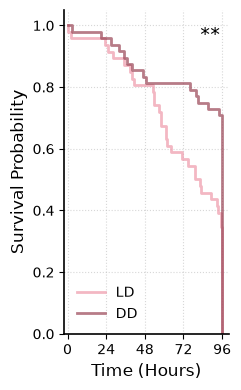

Saved Native Kaplan-Meier plot to: ./Mortality_Plots/mortality_kaplan_meier.svg


In [ ]:
# re running the escaped login here... so we dont need to re run all the chunks above.
if 'is_escaped' not in df_ld.columns:
    escaped_mask = (
        ((df_ld['rep_num'] == 1) & (df_ld['individual'] == 1)) |
        ((df_ld['rep_num'] == 2) & (df_ld['individual'] == 1)) |
        ((df_ld['rep_num'] == 2) & (df_ld['individual'] == 6))
    )
    df_ld['is_escaped'] = escaped_mask
    df_dd['is_escaped'] = False

color_ld = '#EE99AA'  # Light Red
color_dd = '#994455'  # Dark Red

# add the mask 
# an individual is censored (~event) if they escaped OR survived to 96 hours
ld_event_observed = ~(df_ld['is_escaped'] | (df_ld['lifespan'] >= 96))
dd_event_observed = ~(df_dd['is_escaped'] | (df_dd['lifespan'] >= 96))

# functions for the kaplan meier since the lifelines package had issues installign with uv
def calculate_kaplan_meier(durations, events):
    """Calculates step-wise Kaplan-Meier survival probabilities."""
    df = pd.DataFrame({'time': durations, 'event': events}).sort_values('time')
    times = df['time'].unique()
    
    n_risk = len(df)
    survival = 1.0
    
    km_times = [0]
    km_survival = [1.0]
    
    for t in times:
        at_t = df[df['time'] == t]
        deaths = at_t['event'].sum()
        censored = (~at_t['event']).sum()
        
        if n_risk > 0:
            survival *= (1 - (deaths / n_risk))
            
        km_times.append(t)
        km_survival.append(survival)
        
        n_risk -= (deaths + censored)
        
    return km_times, km_survival

def logrank_p_value(durations_A, events_A, durations_B, events_B):
    """Calculates the Log-Rank test statistic using scipy.stats chi2."""
    df_A = pd.DataFrame({'time': durations_A, 'event': events_A})
    df_B = pd.DataFrame({'time': durations_B, 'event': events_B})
    df = pd.concat([df_A, df_B])
    
    times = np.sort(df['time'].unique())
    
    O_A = df_A['event'].sum() 
    E_A = 0.0                 
    V_A = 0.0                 
    
    n_A = len(df_A)
    n_B = len(df_B)
    
    for t in times:
        d_A = df_A[(df_A['time'] == t) & df_A['event']].shape[0]
        c_A = df_A[(df_A['time'] == t) & ~df_A['event']].shape[0]
        d_B = df_B[(df_B['time'] == t) & df_B['event']].shape[0]
        c_B = df_B[(df_B['time'] == t) & ~df_B['event']].shape[0]
        
        d_tot = d_A + d_B
        n_tot = n_A + n_B
        
        if n_tot > 0 and d_tot > 0:
            E_A += d_tot * (n_A / n_tot)
            if n_tot > 1:
                V_A += (d_tot * n_A * n_B * (n_tot - d_tot)) / (n_tot**2 * (n_tot - 1))
                
        n_A -= (d_A + c_A)
        n_B -= (d_B + c_B)
        
    if V_A == 0: return 1.0
    
    Z2 = ((O_A - E_A)**2) / V_A
    return stats.chi2.sf(Z2, df=1)

# set a path for the figure output
OUTPUT_KM_IMG = "./Mortality_Plots/mortality_kaplan_meier.svg"

#set figure to match the same dimensions as the mann whitney boxplot
fig3, ax_km = plt.subplots(figsize=(2.5, 4))
fig3.patch.set_facecolor('white')
ax_km.set_facecolor('white')

# LD survivorship lines
t_ld, s_ld = calculate_kaplan_meier(df_ld['lifespan'], ld_event_observed)
ax_km.step(t_ld, s_ld, where='post', color=color_ld, linewidth=2, label='LD', alpha = 0.7)

# DD survival lines
t_dd, s_dd = calculate_kaplan_meier(df_dd['lifespan'], dd_event_observed)
ax_km.step(t_dd, s_dd, where='post', color=color_dd, linewidth=2, label='DD', alpha = 0.7)

# the log rank test
p_val_km = logrank_p_value(
    df_ld['lifespan'], ld_event_observed,
    df_dd['lifespan'], dd_event_observed
)

# asterisks conditionals
if p_val_km <= 0.0001: sig_km = '****'
elif p_val_km <= 0.001: sig_km = '***'
elif p_val_km <= 0.01: sig_km = '**'
elif p_val_km <= 0.05: sig_km = '*'
else: sig_km = 'ns'

print(f"Stats -> Log-Rank test: p-value = {p_val_km:.4e} ({sig_km})")

# format the plot
ax_km.set_xlabel('Time (h)', fontsize=12)
ax_km.set_ylabel('Survival Probability', fontsize=12)

# 24 h ticks
ax_km.set_xticks([0, 24, 48, 72, 96])
ax_km.set_xlim(-2, 100)
ax_km.set_ylim(0, 1.05)

# format
ax_km.spines['top'].set_visible(False)
ax_km.spines['right'].set_visible(False)
ax_km.spines['bottom'].set_linewidth(1.2)
ax_km.spines['left'].set_linewidth(1.2)
ax_km.grid(axis='both', linestyle=':', alpha=0.5, zorder=0)

ax_km.legend(frameon=False, fontsize=10, loc='lower left')

# plot the p value asterisks annotation
ax_km.text(0.95, 0.95, f'{sig_km}', 
           transform=ax_km.transAxes, ha='right', va='top', 
           fontsize=14, color='black')

fig3.tight_layout()
plt.show()
# save the plot.
fig3.savefig(OUTPUT_KM_IMG, bbox_inches='tight', dpi=300)
print(f"Saved Native Kaplan-Meier plot to: {OUTPUT_KM_IMG}")